In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/Dataset .csv")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print("Dataset Shape:", df.shape)

df[["Aggregate rating", "Votes"]].describe()

Dataset Shape: (9551, 21)


,Aggregate rating,Votes
count,9551.000000,9551.000000
mean,2.666370,156.909748
std,1.516378,430.169145
min,0.000000,0.000000
25%,2.500000,5.000000
50%,3.200000,31.000000
75%,3.700000,131.000000
max,4.900000,10934.000000


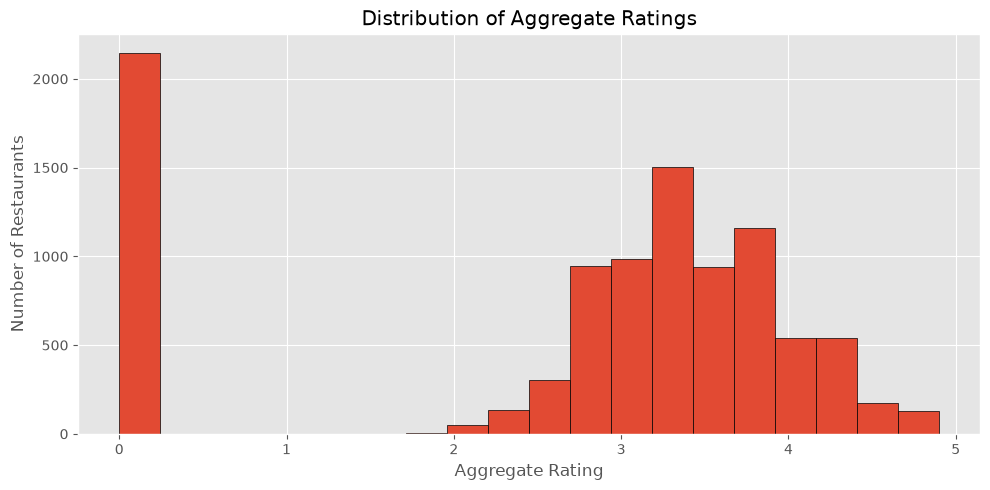

In [3]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Aggregate rating"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

In [5]:
rating_bins = [0,1,2,3,4,5]

rating_labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-4",
    "4-5"
]

df["Rating Range"] = pd.cut(
    df["Aggregate rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

rating_distribution = (
    df["Rating Range"]
    .value_counts()
    .sort_index()
)

print(rating_distribution)

Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64


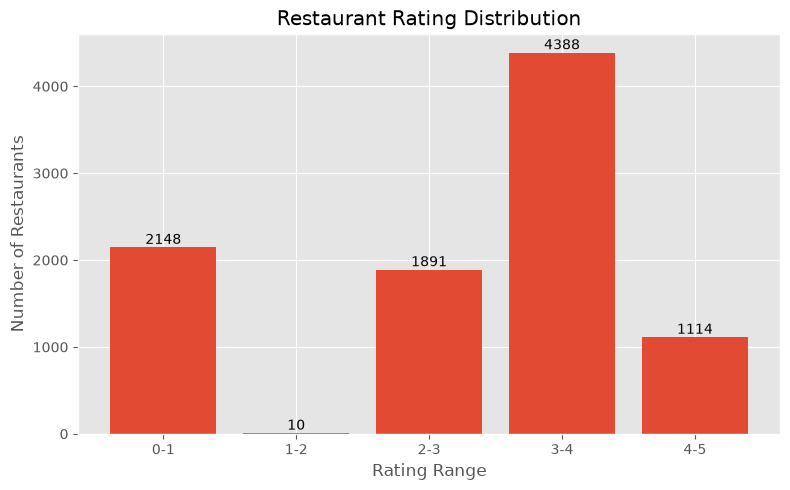

In [6]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    rating_distribution.index.astype(str),
    rating_distribution.values
)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [7]:
average_votes = df["Votes"].mean()

print(f"Average Votes: {average_votes:.2f}")

Average Votes: 156.91


In [8]:
top_votes = (
    df[["Restaurant Name", "Votes", "Aggregate rating"]]
    .sort_values(by="Votes", ascending=False)
    .head(10)
)

top_votes

,Restaurant Name,Votes,Aggregate rating
728,Toit,10934,4.8
735,Truffles,9667,4.7
3994,Hauz Khas Social,7931,4.3
2412,Peter Cat,7574,4.3
739,AB's - Absolute Barbecues,6907,4.6
2414,Barbeque Nation,5966,4.9
743,Big Brewsky,5705,4.5
2307,AB's - Absolute Barbecues,5434,4.9
736,The Black Pearl,5385,4.1
2411,BarBQ,5288,4.2


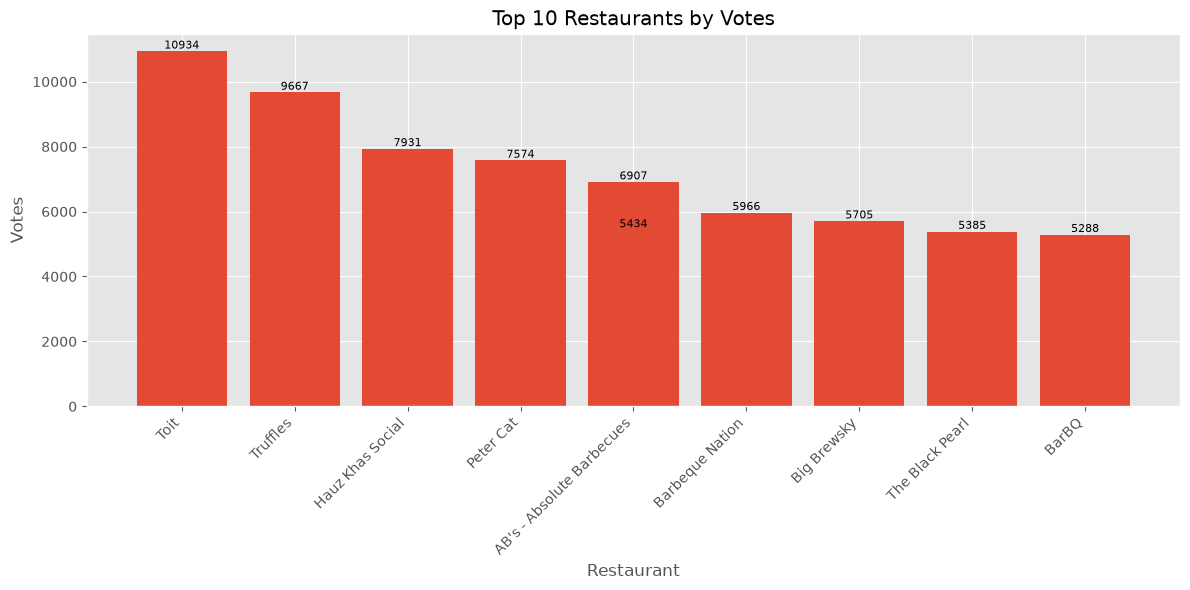

In [9]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_votes["Restaurant Name"],
    top_votes["Votes"]
)

plt.xticks(rotation=45, ha="right")

plt.title("Top 10 Restaurants by Votes")
plt.xlabel("Restaurant")
plt.ylabel("Votes")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [10]:
summary = pd.DataFrame({
    "Average Rating":[df["Aggregate rating"].mean()],
    "Average Votes":[df["Votes"].mean()],
    "Maximum Rating":[df["Aggregate rating"].max()],
    "Maximum Votes":[df["Votes"].max()]
})

summary

,Average Rating,Average Votes,Maximum Rating,Maximum Votes
0,2.66637,156.909748,4.9,10934


# Observations

- Analyzed the distribution of aggregate restaurant ratings.
- Identified the most common rating range.
- Calculated the average number of customer votes received by restaurants.
- Identified the top 10 restaurants based on votes.
- Visualized both rating distribution and restaurant popularity.
- The analysis provides insights into customer satisfaction and engagement.